In [1]:
import matplotlib.pyplot as plt 

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

In [2]:
import torch 
from nnsight import LanguageModel 
model = LanguageModel("meta-llama/Llama-3.1-8B", dispatch=True, device_map="cuda")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
neurons = model.model.layers[18].mlp.down_proj.weight.detach()

In [4]:
import yaml 
from utils import load_subspace_hf

LAYER = 18 
subspace_type = "output"

# focus on addition neurons for this sweep 
cyclic_task = "addition"
config_path = f"../best_das/Llama-3.1-8B/L{LAYER}_{cyclic_task}.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

sub_cfg = config["subspaces"][subspace_type]
output_subspace = load_subspace_hf(cyclic_task, subspace_type, layer=LAYER)
print(f"Loaded {cyclic_task} {subspace_type} subspace: {output_subspace.shape}")
print(f"  IIA: {sub_cfg['subspace_iia']:.3f}")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

  Subspace shape: torch.Size([4096, 16])
Loaded addition output subspace: torch.Size([4096, 16])
  IIA: 0.966


Sweep over thresholds on the `addition` task and measure change in accuracy when zero-ablating. 

In [19]:
from tasks import TASKS

def eval_addition(threshold, maxinp=100):
    cm = TASKS["addition"]["causal_model"]

    addition_neuron_set = set()
    ss = output_subspace.bfloat16()
    with torch.no_grad():
        projs = []
        for i, n in enumerate(neurons.T):
            projs.append(
                ((n @ ss).norm(dim=0) / n.norm(dim=0)).item()
            )
        addition_neuron_set.update(torch.where(torch.tensor(projs) > threshold)[0].cpu().tolist())
    print(f"ablating {len(addition_neuron_set)} neurons: {addition_neuron_set}")

    template = "{a}+{b}="
    prompt_dict = {}
    for a in range(1, 100):
        for b in range(1, 100):
            prompt_dict[(a, b)] = template.format(a=a, b=b)

    answers = []
    for tup, p in prompt_dict.items():
        # ans = cm.run_forward({"input" : tup[0], "number" : tup[1]})["raw_output"]
        ans = str(tup[0] + tup[1])
        answers.append(ans)

    prompts = list(prompt_dict.values())

    # Clean
    with torch.no_grad():
        with model.trace(prompts):
            clean_probs = model.output.logits[:, -1].softmax(dim=-1).save()
    
    # Zero-ablate addition neurons
    with torch.no_grad():
        with model.trace(prompts):
            for neuron_idx in addition_neuron_set:
                model.model.layers[18].mlp.down_proj.input[:, -1, neuron_idx] = 0
            zeroed_probs = model.output.logits[:, -1].softmax(dim=-1).save()
    
    # Flip addition neurons
    with torch.no_grad():
        with model.trace(prompts):
            for neuron_idx in addition_neuron_set:
                model.model.layers[18].mlp.down_proj.input[:, -1, neuron_idx] *= -1
            flipped_probs = model.output.logits[:, -1].softmax(dim=-1).save()
    
    # Keep only addition neurons (zero everything else)
    with torch.no_grad():
        with model.trace(prompts):
            for neuron_idx in range(model.config.intermediate_size):
                if neuron_idx not in addition_neuron_set:
                    model.model.layers[18].mlp.down_proj.input[:, -1, neuron_idx] = 0
            only_probs = model.output.logits[:, -1].softmax(dim=-1).save()

    clean_preds = [model.tokenizer.decode(t) for t in clean_probs.argmax(dim=-1)]
    zeroed_preds = [model.tokenizer.decode(t) for t in zeroed_probs.argmax(dim=-1)]
    flipped_preds = [model.tokenizer.decode(t) for t in flipped_probs.argmax(dim=-1)]
    only_preds = [model.tokenizer.decode(t) for t in only_probs.argmax(dim=-1)]

    clean_acc = sum(p == a for p, a in zip(clean_preds, answers)) / len(answers)
    zeroed_acc = sum(p == a for p, a in zip(zeroed_preds, answers)) / len(answers)
    flipped_acc = sum(p == a for p, a in zip(flipped_preds, answers)) / len(answers)
    only_acc = sum(p == a for p, a in zip(only_preds, answers)) / len(answers)

    if clean_acc < 0.8:
        for pmpt, pred, answer in zip(list(prompt_dict.values()), clean_preds, answers):
            if pred != answer:
                print(repr(pmpt), repr(pred), repr(answer))

    print(f"Addition | template: {template}...")
    print(f"  Clean:              {clean_acc:.2%}")
    print(f"  Neurons zeroed:     {zeroed_acc:.2%}")
    print(f"  Neurons flipped:    {flipped_acc:.2%}")
    print(f"  Only these neurons: {only_acc:.2%}")
    print()

    return {"clean": clean_acc, "zeroed": zeroed_acc, "flipped": flipped_acc, "only": only_acc, "num_neurons" : len(addition_neuron_set), "neuron_list": addition_neuron_set}

In [21]:
import numpy as np

thresholds = np.linspace(0.0, 1.0, 21)
results = {"clean": [], "zeroed": [], "flipped": [], "only": [], "num_neurons": []}
neuron_lists = []

for t in thresholds:
    print(f"=== threshold = {t:.3f} ===")
    res = eval_addition(float(t))
    for k in res.keys():
        if k == "neuron_list":
            print(res[k])
            neuron_lists.append(res[k])
        else:
            results[k].append(res[k])

=== threshold = 0.000 ===
ablating 14336 neurons: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211,

<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2715315/1026259182.py:10: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel("Addition $\omega$ Threshold (higher=stricter, fewer neurons)")
/tmp/ipykernel_2715315/1026259182.py:12: SyntaxWarning: invalid escape sequence '\o'
  ax.set_title(f"$\omega$ Threshold Selection (L{LAYER}, {subspace_type})")


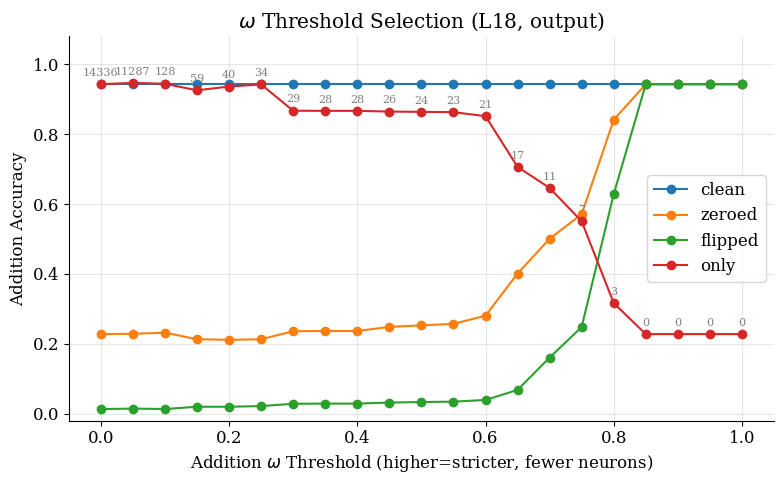

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, accs in results.items():
    if name != "num_neurons":
        ax.plot(thresholds, accs, marker="o", label=name)

for t, acc, n in zip(thresholds, results["only"], results["num_neurons"]):
    ax.annotate(str(n), xy=(t, acc), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=8, color="gray")

ax.set_xlabel("Addition $\omega$ Threshold (higher=stricter, fewer neurons)")
ax.set_ylabel("Addition Accuracy")
ax.set_title(f"$\omega$ Threshold Selection (L{LAYER}, {subspace_type})")
ax.set_ylim(-0.02, 1.08)
ax.legend()
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../outputs/neuron_selection_sweep.pdf")

In [25]:
import json 
print(len(neuron_lists[4]))
with open("extra_addition_neurons.json", 'w') as f:
    json.dump(list(neuron_lists[4]), f)

40
